**NMF**

**NMF on standarized data range (-1,1) with a shift of +1**

Testing NMF with different n_components for RF
------------------------------------------------------------
n_components= 10 | Recon Error: 110.0502 | CV F1: 0.8216
n_components= 16 | Recon Error: 98.3001 | CV F1: 0.8196
n_components= 20 | Recon Error: 92.3263 | CV F1: 0.7933
n_components= 25 | Recon Error: 86.6654 | CV F1: 0.8003
n_components= 32 | Recon Error: 80.0947 | CV F1: 0.8306
n_components= 40 | Recon Error: 73.8095 | CV F1: 0.8043
n_components= 50 | Recon Error: 67.3364 | CV F1: 0.7857
n_components= 75 | Recon Error: 54.7997 | CV F1: 0.8077
n_components=100 | Recon Error: 45.1979 | CV F1: 0.7835
✓ Optimal for RF: 32

Testing NMF with different n_components for SVM
------------------------------------------------------------
n_components= 10 | Recon Error: 110.0502 | CV F1: 0.8673
n_components= 16 | Recon Error: 98.3001 | CV F1: 0.8387
n_components= 20 | Recon Error: 92.3263 | CV F1: 0.8431
n_components= 25 | Recon Error: 86.6654 | CV F1: 0.8271
n_components= 32 | Recon Error:

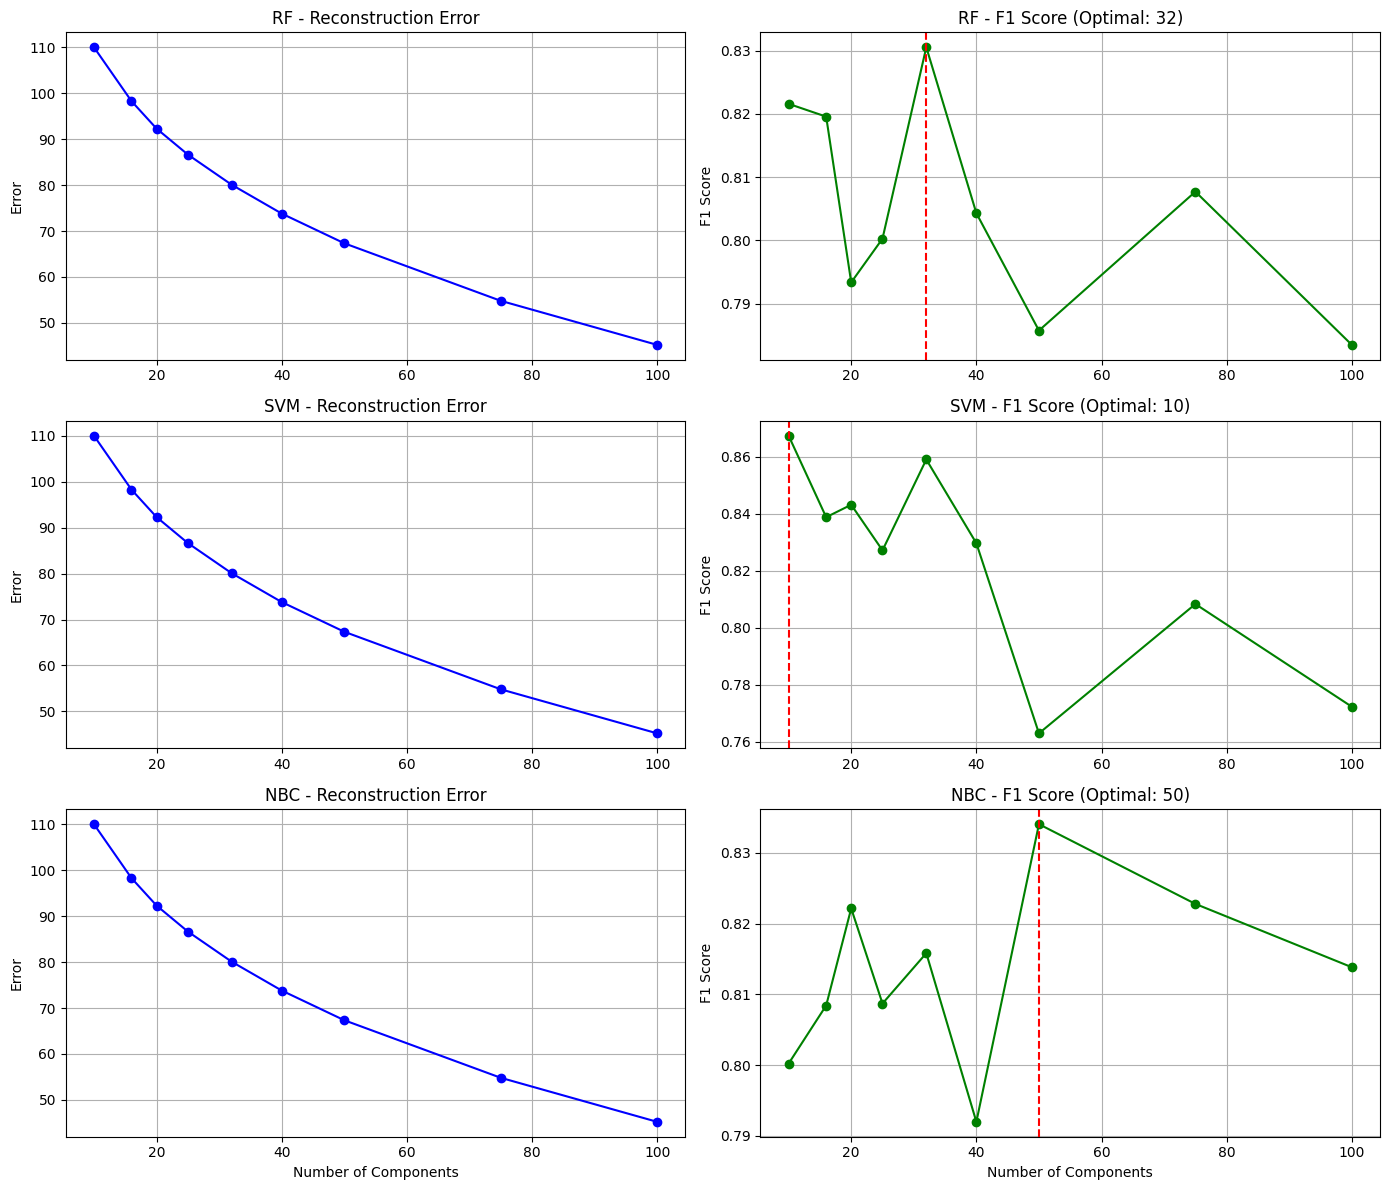


SUMMARY OF OPTIMAL n_components
Random Forest: 32 (F1: 0.8306)
SVM: 10 (F1: 0.8673)
NBC: 50 (F1: 0.8341)


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Load data
X = pd.read_excel('../minmax.xlsx').values
y = pd.read_csv('../idC_with_header.csv').values.flatten() - 1
X = X + 1

components_range = [10, 16, 20, 25, 32, 40, 50, 75, 100]

# Store results for each classifier separately
rf_results = {'n_components': [], 'recon_error': [], 'cv_f1': []}
svm_results = {'n_components': [], 'recon_error': [], 'cv_f1': []}
nbc_results = {'n_components': [], 'recon_error': [], 'cv_f1': []}

# RANDOM FOREST
print("Testing NMF with different n_components for RF")
print("-" * 60)
for n_comp in components_range:
    nmf = NMF(n_components=n_comp, init='random', random_state=0, max_iter=1000)
    X_nmf = nmf.fit_transform(X)
    
    clf = RandomForestClassifier(random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(clf, X_nmf, y, cv=5, scoring='f1_weighted')
    
    rf_results['n_components'].append(n_comp)
    rf_results['recon_error'].append(nmf.reconstruction_err_)
    rf_results['cv_f1'].append(cv_scores.mean())
    
    print(f"n_components={n_comp:3d} | Recon Error: {nmf.reconstruction_err_:.4f} | CV F1: {cv_scores.mean():.4f}")

best_rf = rf_results['n_components'][np.argmax(rf_results['cv_f1'])]
print(f"✓ Optimal for RF: {best_rf}\n")

# SVM
print("Testing NMF with different n_components for SVM")
print("-" * 60)
for n_comp in components_range:
    nmf = NMF(n_components=n_comp, init='random', random_state=0, max_iter=1000)
    X_nmf = nmf.fit_transform(X)
    
    clf = SVC(random_state=42)
    cv_scores = cross_val_score(clf, X_nmf, y, cv=5, scoring='f1_weighted')
    
    svm_results['n_components'].append(n_comp)
    svm_results['recon_error'].append(nmf.reconstruction_err_)
    svm_results['cv_f1'].append(cv_scores.mean())
    
    print(f"n_components={n_comp:3d} | Recon Error: {nmf.reconstruction_err_:.4f} | CV F1: {cv_scores.mean():.4f}")

best_svm = svm_results['n_components'][np.argmax(svm_results['cv_f1'])]
print(f"✓ Optimal for SVM: {best_svm}\n")

# NBC
print("Testing NMF with different n_components for NBC")
print("-" * 60)
for n_comp in components_range:
    nmf = NMF(n_components=n_comp, init='random', random_state=0, max_iter=1000)
    X_nmf = nmf.fit_transform(X)
    
    clf = GaussianNB()
    cv_scores = cross_val_score(clf, X_nmf, y, cv=5, scoring='f1_weighted')
    
    nbc_results['n_components'].append(n_comp)
    nbc_results['recon_error'].append(nmf.reconstruction_err_)
    nbc_results['cv_f1'].append(cv_scores.mean())
    
    print(f"n_components={n_comp:3d} | Recon Error: {nmf.reconstruction_err_:.4f} | CV F1: {cv_scores.mean():.4f}")

best_nbc = nbc_results['n_components'][np.argmax(nbc_results['cv_f1'])]
print(f"✓ Optimal for NBC: {best_nbc}\n")

# Plot comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# RF plots
axes[0, 0].plot(rf_results['n_components'], rf_results['recon_error'], 'bo-')
axes[0, 0].set_title('RF - Reconstruction Error')
axes[0, 0].set_ylabel('Error')
axes[0, 0].grid()

axes[0, 1].plot(rf_results['n_components'], rf_results['cv_f1'], 'go-')
axes[0, 1].axvline(best_rf, color='r', linestyle='--')
axes[0, 1].set_title(f'RF - F1 Score (Optimal: {best_rf})')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].grid()

# SVM plots
axes[1, 0].plot(svm_results['n_components'], svm_results['recon_error'], 'bo-')
axes[1, 0].set_title('SVM - Reconstruction Error')
axes[1, 0].set_ylabel('Error')
axes[1, 0].grid()

axes[1, 1].plot(svm_results['n_components'], svm_results['cv_f1'], 'go-')
axes[1, 1].axvline(best_svm, color='r', linestyle='--')
axes[1, 1].set_title(f'SVM - F1 Score (Optimal: {best_svm})')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].grid()

# NBC plots
axes[2, 0].plot(nbc_results['n_components'], nbc_results['recon_error'], 'bo-')
axes[2, 0].set_title('NBC - Reconstruction Error')
axes[2, 0].set_xlabel('Number of Components')
axes[2, 0].set_ylabel('Error')
axes[2, 0].grid()

axes[2, 1].plot(nbc_results['n_components'], nbc_results['cv_f1'], 'go-')
axes[2, 1].axvline(best_nbc, color='r', linestyle='--')
axes[2, 1].set_title(f'NBC - F1 Score (Optimal: {best_nbc})')
axes[2, 1].set_xlabel('Number of Components')
axes[2, 1].set_ylabel('F1 Score')
axes[2, 1].grid()

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("SUMMARY OF OPTIMAL n_components")
print("="*60)
print(f"Random Forest: {best_rf} (F1: {max(rf_results['cv_f1']):.4f})")
print(f"SVM: {best_svm} (F1: {max(svm_results['cv_f1']):.4f})")
print(f"NBC: {best_nbc} (F1: {max(nbc_results['cv_f1']):.4f})")

**RF**

In [21]:
from sklearn.model_selection import train_test_split

# RF
optimal_n = 32

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf = nmf.fit_transform(X)  # ← Changed X_nmf_RF to X_nmf

print(f"NMF Features Shape: {X_nmf.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf, y, test_size=0.2, random_state=42, stratify=y  # Added stratify
)

# Train Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)  # Added n_jobs for speed
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Evaluate
rf_acc = accuracy_score(y_test, rf_preds)
rf_precision = precision_score(y_test, rf_preds, average='macro')  # Fixed typo
rf_recall = recall_score(y_test, rf_preds, average='macro')
rf_f1 = f1_score(y_test, rf_preds, average='macro')

print(f"Random Forest Accuracy on NMF: {rf_acc * 100:.4f}%")
print(f"Random Forest Precision on NMF: {rf_precision * 100:.4f}%")  # Fixed typo
print(f"Random Forest Recall on NMF: {rf_recall * 100:.4f}%")
print(f"Random Forest F1-Score on NMF: {rf_f1 * 100:.4f}%")

NMF Features Shape: (443, 32)
Random Forest Accuracy on NMF: 89.8876%
Random Forest Precision on NMF: 92.7381%
Random Forest Recall on NMF: 89.0598%
Random Forest F1-Score on NMF: 90.0492%


**SVM**

In [20]:
# SVM with optimal n_components
optimal_n = 10

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf = nmf.fit_transform(X)  # ← Consistent variable name

print(f"NMF Features Shape: {X_nmf.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf, y, test_size=0.2, random_state=42, stratify=y  # Added stratify for balance
)

# Train SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)  # ← Changed from rf to svm

# Evaluate
svm_acc = accuracy_score(y_test, svm_preds)
svm_precision = precision_score(y_test, svm_preds, average='macro')  # Fixed typo
svm_recall = recall_score(y_test, svm_preds, average='macro')
svm_f1 = f1_score(y_test, svm_preds, average='macro')

print(f"SVM Accuracy on NMF: {svm_acc * 100:.4f}%")
print(f"SVM Precision on NMF: {svm_precision * 100:.4f}%")  # Fixed typo
print(f"SVM Recall on NMF: {svm_recall * 100:.4f}%")
print(f"SVM F1-Score on NMF: {svm_f1 * 100:.4f}%")

NMF Features Shape: (443, 10)
SVM Accuracy on NMF: 87.6404%
SVM Precision on NMF: 91.3379%
SVM Recall on NMF: 86.8620%
SVM F1-Score on NMF: 87.8197%


In [14]:
# SVM with optimal n_components
optimal_n = 32

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf = nmf.fit_transform(X)  # ← Consistent variable name

print(f"NMF Features Shape: {X_nmf.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf, y, test_size=0.2, random_state=42, stratify=y  # Added stratify for balance
)

# Train SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)  # ← Changed from rf to svm

# Evaluate
svm_acc = accuracy_score(y_test, svm_preds)
svm_precision = precision_score(y_test, svm_preds, average='macro')  # Fixed typo
svm_recall = recall_score(y_test, svm_preds, average='macro')
svm_f1 = f1_score(y_test, svm_preds, average='macro')

print(f"SVM Accuracy on NMF: {svm_acc * 100:.4f}%")
print(f"SVM Precision on NMF: {svm_precision * 100:.4f}%")  # Fixed typo
print(f"SVM Recall on NMF: {svm_recall * 100:.4f}%")
print(f"SVM F1-Score on NMF: {svm_f1 * 100:.4f}%")

NMF Features Shape: (443, 32)
SVM Accuracy on NMF: 79.7753%
SVM Precision on NMF: 79.3622%
SVM Recall on NMF: 74.6886%
SVM F1-Score on NMF: 75.1024%


**NBC**

In [22]:
# NBC
optimal_n = 50

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf_NBC = nmf.fit_transform(X)

print(f"NMF Features Shape: {X_nmf_NBC.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf_NBC, y, test_size=0.2, random_state=42, stratify=y  # Added stratify
)

# Train Naive Bayes
nbc = GaussianNB()
nbc.fit(X_train, y_train)
nbc_preds = nbc.predict(X_test)

# Evaluate
nbc_acc = accuracy_score(y_test, nbc_preds)
nbc_precision = precision_score(y_test, nbc_preds, average='macro')  # Fixed typo
nbc_recall = recall_score(y_test, nbc_preds, average='macro')
nbc_f1 = f1_score(y_test, nbc_preds, average='macro')

print(f"Naive Bayes Accuracy on NMF: {nbc_acc * 100:.4f}%")
print(f"Naive Bayes Precision on NMF: {nbc_precision * 100:.4f}%")
print(f"Naive Bayes Recall on NMF: {nbc_recall * 100:.4f}%")
print(f"Naive Bayes F1-Score on NMF: {nbc_f1 * 100:.4f}%")

NMF Features Shape: (443, 50)
Naive Bayes Accuracy on NMF: 83.1461%
Naive Bayes Precision on NMF: 79.6844%
Naive Bayes Recall on NMF: 76.0256%
Naive Bayes F1-Score on NMF: 75.9507%


In [13]:
# NBC
optimal_n = 32

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf_NBC = nmf.fit_transform(X)

print(f"NMF Features Shape: {X_nmf_NBC.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf_NBC, y, test_size=0.2, random_state=42, stratify=y  # Added stratify
)

# Train Naive Bayes
nbc = GaussianNB()
nbc.fit(X_train, y_train)
nbc_preds = nbc.predict(X_test)

# Evaluate
nbc_acc = accuracy_score(y_test, nbc_preds)
nbc_precision = precision_score(y_test, nbc_preds, average='macro')  # Fixed typo
nbc_recall = recall_score(y_test, nbc_preds, average='macro')
nbc_f1 = f1_score(y_test, nbc_preds, average='macro')

print(f"Naive Bayes Accuracy on NMF: {nbc_acc * 100:.4f}%")
print(f"Naive Bayes Precision on NMF: {nbc_precision * 100:.4f}%")
print(f"Naive Bayes Recall on NMF: {nbc_recall * 100:.4f}%")
print(f"Naive Bayes F1-Score on NMF: {nbc_f1 * 100:.4f}%")

NMF Features Shape: (443, 32)
Naive Bayes Accuracy on NMF: 86.5169%
Naive Bayes Precision on NMF: 90.2508%
Naive Bayes Recall on NMF: 86.0379%
Naive Bayes F1-Score on NMF: 87.2241%


**Using a Different range for minmax standarization**

**Standarizing using minmax with range (0,1)**

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.read_excel('trans.xlsx')

scaler = MinMaxScaler(feature_range=(0,1))
normalized_data = scaler.fit_transform(data)

normalized_df = pd.DataFrame(normalized_data, columns=data.columns)


normalized_df.to_excel('minmax01.xlsx', index=False)

# Display the first few rows of the normalized data
print(normalized_df.head())

        1         2         3         4         5         6         7    \
0  0.623776  0.620973  0.612662  0.588360  0.543099  0.479857  0.495796   
1  0.652399  0.644070  0.628702  0.594572  0.534844  0.467821  0.496505   
2  0.542665  0.547587  0.552135  0.553631  0.574623  0.584765  0.608331   
3  0.533469  0.527957  0.517214  0.492246  0.483462  0.509704  0.579894   
4  0.629541  0.628082  0.622509  0.604742  0.570688  0.511940  0.522276   

        8         9         10   ...       891       892       893       894  \
0  0.453956  0.411099  0.371012  ...  0.584263  0.561997  0.550815  0.557947   
1  0.471036  0.447643  0.432884  ...  0.449303  0.421185  0.414511  0.438280   
2  0.556460  0.501144  0.447417  ...  0.305350  0.261497  0.244257  0.263913   
3  0.563193  0.539103  0.520761  ...  0.460385  0.427088  0.414534  0.431125   
4  0.477686  0.434864  0.397144  ...  0.490343  0.458367  0.445306  0.459366   

        895       896       897       898       899       900  
0  0

**NMF with data standarized with range (0,1)**

Testing NMF with different n_components for RF
------------------------------------------------------------
n_components= 10 | Recon Error: 55.0251 | CV F1: 0.8216
n_components= 16 | Recon Error: 49.1501 | CV F1: 0.8196
n_components= 20 | Recon Error: 46.1632 | CV F1: 0.7933
n_components= 25 | Recon Error: 43.3327 | CV F1: 0.8003
n_components= 32 | Recon Error: 40.0473 | CV F1: 0.8306
n_components= 40 | Recon Error: 36.9048 | CV F1: 0.8043
n_components= 50 | Recon Error: 33.6682 | CV F1: 0.7857
n_components= 75 | Recon Error: 27.3999 | CV F1: 0.8077
n_components=100 | Recon Error: 22.5989 | CV F1: 0.7835
✓ Optimal for RF: 32

Testing NMF with different n_components for SVM
------------------------------------------------------------
n_components= 10 | Recon Error: 55.0251 | CV F1: 0.8673
n_components= 16 | Recon Error: 49.1501 | CV F1: 0.8387
n_components= 20 | Recon Error: 46.1632 | CV F1: 0.8431
n_components= 25 | Recon Error: 43.3327 | CV F1: 0.8271
n_components= 32 | Recon Error: 4

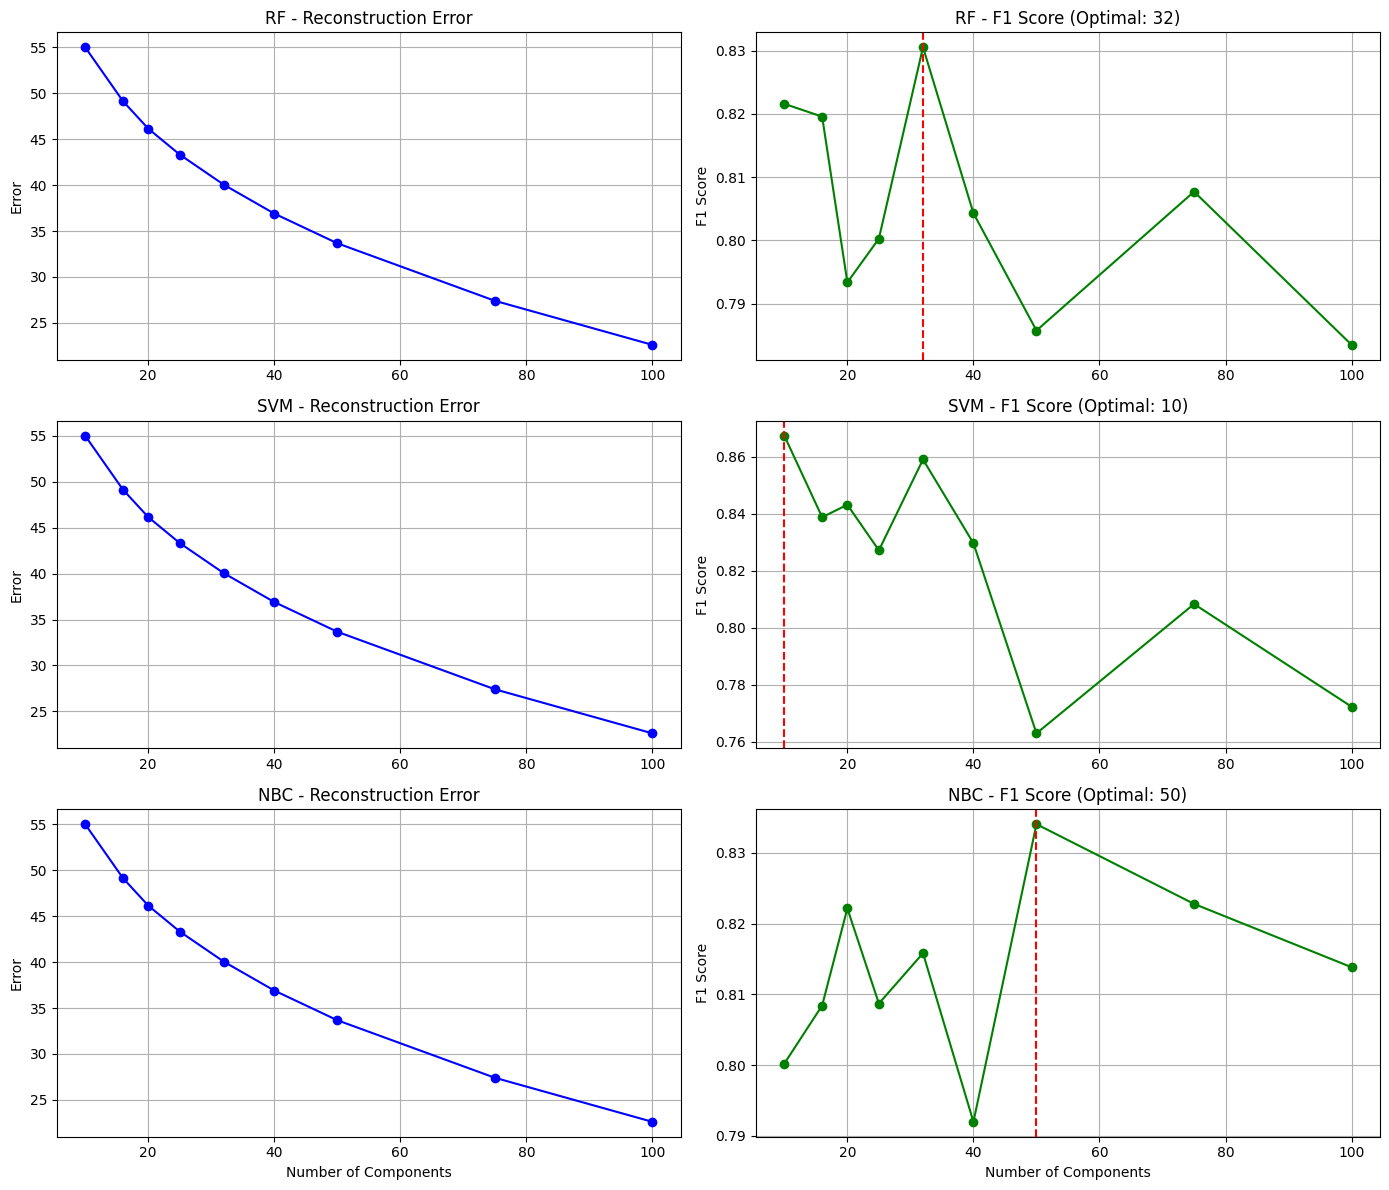


SUMMARY OF OPTIMAL n_components
Random Forest: 32 (F1: 0.8306)
SVM: 10 (F1: 0.8673)
NBC: 50 (F1: 0.8341)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')
#import time

# Load data
X0 = pd.read_excel('minmax01.xlsx').values
y = pd.read_csv('../idC_with_header.csv').values.flatten() - 1

components_range0 = [10, 16, 20, 25, 32, 40, 50, 75, 100]

# Store results for each classifier separately
rf_results0 = {'n_components': [], 'recon_error': [], 'cv_f1': []}
svm_results0 = {'n_components': [], 'recon_error': [], 'cv_f1': []}
nbc_results0 = {'n_components': [], 'recon_error': [], 'cv_f1': []}

# RANDOM FOREST
print("Testing NMF with different n_components for RF")
print("-" * 60)
for n_comp in components_range0:
    nmf = NMF(n_components=n_comp, init='random', random_state=0, max_iter=1000)
    X_nmf0 = nmf.fit_transform(X0)
    
    clf = RandomForestClassifier(random_state=42, n_jobs=-1)
    cv_scores = cross_val_score(clf, X_nmf0, y, cv=5, scoring='f1_weighted')
    
    rf_results0['n_components'].append(n_comp)
    rf_results0['recon_error'].append(nmf.reconstruction_err_)
    rf_results0['cv_f1'].append(cv_scores.mean())
    
    print(f"n_components={n_comp:3d} | Recon Error: {nmf.reconstruction_err_:.4f} | CV F1: {cv_scores.mean():.4f}")

best_rf0 = rf_results0['n_components'][np.argmax(rf_results0['cv_f1'])]
print(f"✓ Optimal for RF: {best_rf0}\n")

# SVM
print("Testing NMF with different n_components for SVM")
print("-" * 60)
for n_comp in components_range0:
    nmf = NMF(n_components=n_comp, init='random', random_state=0, max_iter=1000)
    X_nmf0 = nmf.fit_transform(X0)
    
    clf = SVC(random_state=42)
    cv_scores = cross_val_score(clf, X_nmf0, y, cv=5, scoring='f1_weighted')
    
    svm_results0['n_components'].append(n_comp)
    svm_results0['recon_error'].append(nmf.reconstruction_err_)
    svm_results0['cv_f1'].append(cv_scores.mean())
    
    print(f"n_components={n_comp:3d} | Recon Error: {nmf.reconstruction_err_:.4f} | CV F1: {cv_scores.mean():.4f}")

best_svm0 = svm_results0['n_components'][np.argmax(svm_results0['cv_f1'])]
print(f"✓ Optimal for SVM: {best_svm0}\n")

# NBC
print("Testing NMF with different n_components for NBC")
print("-" * 60)
for n_comp in components_range0:
    nmf = NMF(n_components=n_comp, init='random', random_state=0, max_iter=1000)
    X_nmf0 = nmf.fit_transform(X0)
    
    clf = GaussianNB()
    cv_scores = cross_val_score(clf, X_nmf0, y, cv=5, scoring='f1_weighted')
    
    nbc_results0['n_components'].append(n_comp)
    nbc_results0['recon_error'].append(nmf.reconstruction_err_)
    nbc_results0['cv_f1'].append(cv_scores.mean())
    
    print(f"n_components={n_comp:3d} | Recon Error: {nmf.reconstruction_err_:.4f} | CV F1: {cv_scores.mean():.4f}")

best_nbc0 = nbc_results0['n_components'][np.argmax(nbc_results0['cv_f1'])]
print(f"✓ Optimal for NBC: {best_nbc0}\n")

# Plot comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# RF plots
axes[0, 0].plot(rf_results0['n_components'], rf_results0['recon_error'], 'bo-')
axes[0, 0].set_title('RF - Reconstruction Error')
axes[0, 0].set_ylabel('Error')
axes[0, 0].grid()

axes[0, 1].plot(rf_results0['n_components'], rf_results0['cv_f1'], 'go-')
axes[0, 1].axvline(best_rf0, color='r', linestyle='--')
axes[0, 1].set_title(f'RF - F1 Score (Optimal: {best_rf0})')
axes[0, 1].set_ylabel('F1 Score')
axes[0, 1].grid()

# SVM plots
axes[1, 0].plot(svm_results0['n_components'], svm_results0['recon_error'], 'bo-')
axes[1, 0].set_title('SVM - Reconstruction Error')
axes[1, 0].set_ylabel('Error')
axes[1, 0].grid()

axes[1, 1].plot(svm_results0['n_components'], svm_results0['cv_f1'], 'go-')
axes[1, 1].axvline(best_svm0, color='r', linestyle='--')
axes[1, 1].set_title(f'SVM - F1 Score (Optimal: {best_svm0})')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].grid()

# NBC plots
axes[2, 0].plot(nbc_results0['n_components'], nbc_results0['recon_error'], 'bo-')
axes[2, 0].set_title('NBC - Reconstruction Error')
axes[2, 0].set_xlabel('Number of Components')
axes[2, 0].set_ylabel('Error')
axes[2, 0].grid()

axes[2, 1].plot(nbc_results0['n_components'], nbc_results0['cv_f1'], 'go-')
axes[2, 1].axvline(best_nbc0, color='r', linestyle='--')
axes[2, 1].set_title(f'NBC - F1 Score (Optimal: {best_nbc0})')
axes[2, 1].set_xlabel('Number of Components')
axes[2, 1].set_ylabel('F1 Score')
axes[2, 1].grid()

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
print("SUMMARY OF OPTIMAL n_components")
print("="*60)
print(f"Random Forest: {best_rf0} (F1: {max(rf_results0['cv_f1']):.4f})")
print(f"SVM: {best_svm0} (F1: {max(svm_results0['cv_f1']):.4f})")
print(f"NBC: {best_nbc0} (F1: {max(nbc_results0['cv_f1']):.4f})")

In [7]:
from sklearn.model_selection import train_test_split

# RF
optimal_n = 32

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf0 = nmf.fit_transform(X0)  # ← Changed X_nmf_RF to X_nmf

print(f"NMF Features Shape: {X_nmf0.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf0, y, test_size=0.2, random_state=42, stratify=y  # Added stratify
)

# Train Random Forest
rf0 = RandomForestClassifier(random_state=42, n_jobs=-1)  # Added n_jobs for speed
rf0.fit(X_train, y_train)
rf0_preds = rf0.predict(X_test)

# Evaluate
rf_acc0 = accuracy_score(y_test, rf0_preds)
rf_precision0 = precision_score(y_test, rf0_preds, average='macro')  # Fixed typo
rf_recall0 = recall_score(y_test, rf0_preds, average='macro')
rf_f10 = f1_score(y_test, rf0_preds, average='macro')

print(f"Random Forest Accuracy on NMF: {rf_acc0 * 100:.4f}%")
print(f"Random Forest Precision on NMF: {rf_precision0 * 100:.4f}%")  # Fixed typo
print(f"Random Forest Recall on NMF: {rf_recall0 * 100:.4f}%")
print(f"Random Forest F1-Score on NMF: {rf_f10 * 100:.4f}%")

NMF Features Shape: (443, 32)
Random Forest Accuracy on NMF: 89.8876%
Random Forest Precision on NMF: 92.7381%
Random Forest Recall on NMF: 89.0598%
Random Forest F1-Score on NMF: 90.0492%


In [8]:
# SVM with optimal n_components
optimal_n = 10

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf0 = nmf.fit_transform(X0)  # ← Consistent variable name

print(f"NMF Features Shape: {X_nmf0.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf0, y, test_size=0.2, random_state=42, stratify=y  # Added stratify for balance
)

# Train SVM
svm0 = SVC(random_state=42)
svm0.fit(X_train, y_train)
svm0_preds = svm0.predict(X_test)  # ← Changed from rf to svm

# Evaluate
svm_acc0 = accuracy_score(y_test, svm0_preds)
svm_precision0 = precision_score(y_test, svm0_preds, average='macro')  # Fixed typo
svm_recall0 = recall_score(y_test, svm0_preds, average='macro')
svm_f10 = f1_score(y_test, svm0_preds, average='macro')

print(f"SVM Accuracy on NMF: {svm_acc0 * 100:.4f}%")
print(f"SVM Precision on NMF: {svm_precision0 * 100:.4f}%")  # Fixed typo
print(f"SVM Recall on NMF: {svm_recall0 * 100:.4f}%")
print(f"SVM F1-Score on NMF: {svm_f10 * 100:.4f}%")

NMF Features Shape: (443, 10)
SVM Accuracy on NMF: 87.6404%
SVM Precision on NMF: 91.3379%
SVM Recall on NMF: 86.8620%
SVM F1-Score on NMF: 87.8197%


In [12]:
# SVM with optimal n_components
optimal_n = 32

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf0 = nmf.fit_transform(X0)  # ← Consistent variable name

print(f"NMF Features Shape: {X_nmf0.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf0, y, test_size=0.2, random_state=42, stratify=y  # Added stratify for balance
)

# Train SVM
svm0 = SVC(random_state=42)
svm0.fit(X_train, y_train)
svm0_preds = svm0.predict(X_test)  # ← Changed from rf to svm

# Evaluate
svm_acc0 = accuracy_score(y_test, svm0_preds)
svm_precision0 = precision_score(y_test, svm0_preds, average='macro')  # Fixed typo
svm_recall0 = recall_score(y_test, svm0_preds, average='macro')
svm_f10 = f1_score(y_test, svm0_preds, average='macro')

print(f"SVM Accuracy on NMF: {svm_acc0 * 100:.4f}%")
print(f"SVM Precision on NMF: {svm_precision0 * 100:.4f}%")  # Fixed typo
print(f"SVM Recall on NMF: {svm_recall0 * 100:.4f}%")
print(f"SVM F1-Score on NMF: {svm_f10 * 100:.4f}%")

NMF Features Shape: (443, 32)
SVM Accuracy on NMF: 91.0112%
SVM Precision on NMF: 92.9889%
SVM Recall on NMF: 89.1819%
SVM F1-Score on NMF: 90.0782%


In [10]:
# NBC
optimal_n = 50

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf_NBC0 = nmf.fit_transform(X0)

print(f"NMF Features Shape: {X_nmf_NBC0.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf_NBC0, y, test_size=0.2, random_state=42, stratify=y  # Added stratify
)

# Train Naive Bayes
nbc0 = GaussianNB()
nbc0.fit(X_train, y_train)
nbc0_preds = nbc0.predict(X_test)

# Evaluate
nbc_acc0 = accuracy_score(y_test, nbc0_preds)
nbc_precision0 = precision_score(y_test, nbc0_preds, average='macro')  # Fixed typo
nbc_recall0 = recall_score(y_test, nbc0_preds, average='macro')
nbc_f10 = f1_score(y_test, nbc0_preds, average='macro')

print(f"Naive Bayes Accuracy on NMF: {nbc_acc0 * 100:.4f}%")
print(f"Naive Bayes Precision on NMF: {nbc_precision0 * 100:.4f}%")
print(f"Naive Bayes Recall on NMF: {nbc_recall0 * 100:.4f}%")
print(f"Naive Bayes F1-Score on NMF: {nbc_f10 * 100:.4f}%")

NMF Features Shape: (443, 50)
Naive Bayes Accuracy on NMF: 83.1461%
Naive Bayes Precision on NMF: 79.6844%
Naive Bayes Recall on NMF: 76.0256%
Naive Bayes F1-Score on NMF: 75.9507%


In [11]:
# NBC
optimal_n = 32

# Apply NMF
nmf = NMF(n_components=optimal_n, init='random', random_state=0, max_iter=1000)
X_nmf_NBC0 = nmf.fit_transform(X0)

print(f"NMF Features Shape: {X_nmf_NBC0.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_nmf_NBC0, y, test_size=0.2, random_state=42, stratify=y  # Added stratify
)

# Train Naive Bayes
nbc0 = GaussianNB()
nbc0.fit(X_train, y_train)
nbc0_preds = nbc0.predict(X_test)

# Evaluate
nbc_acc0 = accuracy_score(y_test, nbc0_preds)
nbc_precision0 = precision_score(y_test, nbc0_preds, average='macro')  # Fixed typo
nbc_recall0 = recall_score(y_test, nbc0_preds, average='macro')
nbc_f10 = f1_score(y_test, nbc0_preds, average='macro')

print(f"Naive Bayes Accuracy on NMF: {nbc_acc0 * 100:.4f}%")
print(f"Naive Bayes Precision on NMF: {nbc_precision0 * 100:.4f}%")
print(f"Naive Bayes Recall on NMF: {nbc_recall0 * 100:.4f}%")
print(f"Naive Bayes F1-Score on NMF: {nbc_f10 * 100:.4f}%")

NMF Features Shape: (443, 32)
Naive Bayes Accuracy on NMF: 85.3933%
Naive Bayes Precision on NMF: 89.1295%
Naive Bayes Recall on NMF: 85.7082%
Naive Bayes F1-Score on NMF: 86.6198%
